# Chapter 1: Introduction to AI Data Engineering

This notebook mirrors the book's two recurring reference systems:

- a retail ranking platform for traditional ML data engineering
- a retrieval-based support assistant for prompt, context, and tool-trace engineering

The goal is diagnostic rather than implementation-heavy. Use the walkthrough to decide when a system has crossed from analytics engineering into AI data engineering and which assets make that boundary operationally important.

## Learning Objectives
- explain why many production AI failures come from data-layer fragility rather than model architecture alone
- identify the AI-specific assets in both the retail ranking and support-assistant tracks
- compare batch and streaming pressure without losing sight of evaluation, retrieval, and prompt/context assets
- distinguish casual prompting from production prompt and context engineering


## Part 1: The AI Data Lifecycle

Use the lifecycle here as a vocabulary map, not a complete architecture. In the retail ranking track, the system turns events, labels, and features into ranked decisions and feedback. In the support-assistant track, the system turns documents, chunks, prompt templates, retrieved context, and tool outputs into answers and traces.

Across both tracks, the same question matters: which assets have become operational enough that they need versioning, ownership, replay, and evaluation discipline?

Chapter 1 is a boundary-setting chapter, so the code stays deliberately small. The goal is to isolate one design pressure at a time and ask whether the system needs offline rebuilds, online state, evaluation assets, or runtime-context controls.

If a cell looks toy-sized, read it as a diagnostic scaffold. Later notebooks use the same two reference tracks and turn them into storage, architecture, transformation, governance, and release decisions.


## Part 1A: Asset Boundary Table

A workflow becomes an AI data platform when the platform has to preserve more than current business state. The table below makes that boundary visible by mixing retail and assistant assets and asking which ones need versioning, replay, and explicit failure analysis.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import json

def find_companion_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "datasets").exists() and (candidate / "code").exists():
            return candidate
    raise FileNotFoundError("Could not find companion repository root.")

def ensure_path_exists(path: Path, kind: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing expected {kind}: {path}. "
            "Make sure you are running this notebook from inside the companion repository."
        )
    return path

NOTEBOOK_DIR = Path.cwd()
COMPANION_ROOT = find_companion_root(NOTEBOOK_DIR)
print("Libraries imported. The notebook uses small examples only to expose Chapter 1 trade-offs.")

Libraries imported. The notebook uses small examples only to expose Chapter 1 trade-offs.


In [7]:
asset_inventory = pd.DataFrame([
    {
        'asset_name': 'session_events',
        'track': 'retail',
        'asset_type': 'event_stream',
        'needs_versioning': 'yes',
        'needs_replay': 'yes',
        'failure_if_unmanaged': 'stale or missing features',
    },
    {
        'asset_name': 'label_snapshot_v3',
        'track': 'retail',
        'asset_type': 'label_set',
        'needs_versioning': 'yes',
        'needs_replay': 'yes',
        'failure_if_unmanaged': 'unreproducible training',
    },
    {
        'asset_name': 'support_docs_v14',
        'track': 'assistant',
        'asset_type': 'corpus',
        'needs_versioning': 'yes',
        'needs_replay': 'yes',
        'failure_if_unmanaged': 'stale retrieval',
    },
    {
        'asset_name': 'prompt_template_v7',
        'track': 'assistant',
        'asset_type': 'prompt_asset',
        'needs_versioning': 'yes',
        'needs_replay': 'yes',
        'failure_if_unmanaged': 'silent behavior change',
    },
    {
        'asset_name': 'tool_trace_log',
        'track': 'assistant',
        'asset_type': 'runtime_trace',
        'needs_versioning': 'yes',
        'needs_replay': 'partial',
        'failure_if_unmanaged': 'irreproducible answer',
    },
])
asset_inventory


,asset_name,track,asset_type,needs_versioning,needs_replay,failure_if_unmanaged
0,session_events,retail,event_stream,yes,yes,stale or missing features
1,label_snapshot_v3,retail,label_set,yes,yes,unreproducible training
2,support_docs_v14,assistant,corpus,yes,yes,stale retrieval
3,prompt_template_v7,assistant,prompt_asset,yes,yes,silent behavior change
4,tool_trace_log,assistant,runtime_trace,yes,partial,irreproducible answer


### What the Asset Table Should Tell You

If the rows above feel like ordinary warehouse tables, the platform boundary is still blurry. If they feel like assets that must be versioned, replayed, governed, and tied to failure analysis, then the system has crossed from analytics workflow into AI platform behavior.


## Part 1B: Broken Asset Table

A platform diagnosis gets sharper when the same asset list is shown in a broken state. The table below removes the controls Chapter 1 is trying to make visible so the first likely production failure becomes easier to spot.


In [5]:
broken_asset_inventory = pd.DataFrame([
    {
        'asset_name': 'session_events',
        'track': 'retail',
        'asset_type': 'event_stream',
        'needs_versioning': 'no',
        'needs_replay': 'no',
        'failure_if_unmanaged': 'live session features go stale with no replay boundary',
    },
    {
        'asset_name': 'label_snapshot_latest',
        'track': 'retail',
        'asset_type': 'label_set',
        'needs_versioning': 'no',
        'needs_replay': 'no',
        'failure_if_unmanaged': 'training results cannot be reproduced after relabeling',
    },
    {
        'asset_name': 'support_docs_current',
        'track': 'assistant',
        'asset_type': 'corpus',
        'needs_versioning': 'no',
        'needs_replay': 'partial',
        'failure_if_unmanaged': 'retrieval uses stale or ambiguous corpus state',
    },
    {
        'asset_name': 'prompt_template_live',
        'track': 'assistant',
        'asset_type': 'prompt_asset',
        'needs_versioning': 'no',
        'needs_replay': 'no',
        'failure_if_unmanaged': 'behavior changes silently after a prompt edit',
    },
    {
        'asset_name': 'tool_trace_log',
        'track': 'assistant',
        'asset_type': 'runtime_trace',
        'needs_versioning': 'no',
        'needs_replay': 'partial',
        'failure_if_unmanaged': 'the team cannot reconstruct which tool output shaped the answer',
    },
])
broken_asset_inventory


,asset_name,track,asset_type,needs_versioning,needs_replay,failure_if_unmanaged
0,session_events,retail,event_stream,no,no,live session features go stale with no replay ...
1,label_snapshot_latest,retail,label_set,no,no,training results cannot be reproduced after re...
2,support_docs_current,assistant,corpus,no,partial,retrieval uses stale or ambiguous corpus state
3,prompt_template_live,assistant,prompt_asset,no,no,behavior changes silently after a prompt edit
4,tool_trace_log,assistant,runtime_trace,no,partial,the team cannot reconstruct which tool output ...


### Written Exercise

Which row creates the first production failure, and why? A strong answer should name the asset, the first visible symptom, and the missing evidence that would slow the investigation.


### Short Answer Key

In the retail track, `label_snapshot_latest` creates a reproducibility failure after relabeling because there is no stable version boundary to rebuild the training set later. In the assistant track, `prompt_template_live` creates silent behavior change because a prompt edit can change runtime behavior with no versioned rollback target.


## Part 1C: Inspect the Diagnostic Worksheet

The chapter pairs this notebook with a compact diagnostic artifact. Use it as a checklist for deciding when labels, prompts, corpora, and live context have become platform assets instead of notebook conveniences.

In [8]:
diagnostic_path = ensure_path_exists(
    COMPANION_ROOT / "artifacts" / "introduction" / "ai_platform_diagnostic.md",
    "artifact",
)
print("Diagnostic worksheet preview:")
print("-" * 60)
print("\n".join(diagnostic_path.read_text(encoding="utf-8").splitlines()[:18]))

Diagnostic worksheet preview:
------------------------------------------------------------
# AI Platform Diagnostic

- Does the system have both offline and online paths?
- Are labels versioned?
- Are evaluation datasets stable?
- Are embeddings or retrieval corpora treated as first-class assets?
- Is replay required after late data, relabeling, or corpus updates?


## Part 2: Batch vs. Streaming Architectures

The examples in this section keep the data simple on purpose. What matters is the contract around the data: bounded versus continuous input, offline versus online behavior, and easy replay versus live state management.


In [9]:
# Example: Generating sample transaction data
np.random.seed(42)
base_time = datetime(2026, 1, 15, 12, 0, 0)

# Batch data - daily transactions accumulated
batch_data = {
    'transaction_id': range(1, 1001),
    'user_id': np.random.randint(1000, 2000, 1000),
    'amount': np.random.uniform(10, 500, 1000).round(2),
    'timestamp': [base_time - timedelta(hours=i) for i in range(1000)]
}

batch_df = pd.DataFrame(batch_data)
print("Batch Data (first 5 rows):")
print(batch_df.head())
print(f"\nTotal transactions in batch: {len(batch_df)}")
print(f"\nBatch Statistics:")
print(batch_df['amount'].describe())


Batch Data (first 5 rows):
   transaction_id  user_id  amount           timestamp
0               1     1102   32.16 2026-01-15 12:00:00
1               2     1435   22.92 2026-01-15 11:00:00
2               3     1860  194.47 2026-01-15 10:00:00
3               4     1270  407.17 2026-01-15 09:00:00
4               5     1106  493.77 2026-01-15 08:00:00

Total transactions in batch: 1000

Batch Statistics:
count    1000.000000
mean      253.748390
std       142.774818
min        12.270000
25%       125.362500
50%       254.160000
75%       376.277500
max       499.860000
Name: amount, dtype: float64


### Understanding Batch Data

Above, the code generates a toy batch of transactions only to make one chapter-level idea visible: a batch job sees a bounded historical slice all at once. In the retail ranking track, that is the natural shape for nightly training-set rebuilds and benchmark refreshes. In the support-assistant track, the equivalent is a bounded document or evaluation export rather than a live response path.

When you inspect the output, do not focus on the exact numbers. Focus on what the code assumes:

- the input boundary is known in advance;
- the system can compute full-dataset statistics before acting;
- replay is easy because the batch is a bounded object;
- freshness is weaker because the platform waits for accumulation.

That is why batch fits offline learning and reconciliation better than user-facing response paths.

In [10]:
# Streaming data - arriving in real-time (simulated)
print("Streaming Data Simulation (events arriving one at a time):")
print("\nTimestamp\t\tUser_ID\t\tAmount\t\tCumulative Avg")
print("-" * 70)

streaming_amounts = []
for idx in range(10):
    user_id = batch_df.iloc[idx]['user_id']
    amount = batch_df.iloc[idx]['amount']
    streaming_amounts.append(amount)
    cumulative_avg = np.mean(streaming_amounts)
    print(f"{batch_df.iloc[idx]['timestamp']}\t{int(user_id)}\t\t${amount:.2f}\t\t${cumulative_avg:.2f}")

Streaming Data Simulation (events arriving one at a time):

Timestamp		User_ID		Amount		Cumulative Avg
----------------------------------------------------------------------
2026-01-15 12:00:00	1102		$32.16		$32.16
2026-01-15 11:00:00	1435		$22.92		$27.54
2026-01-15 10:00:00	1860		$194.47		$83.18
2026-01-15 09:00:00	1270		$407.17		$164.18
2026-01-15 08:00:00	1106		$493.77		$230.10
2026-01-15 07:00:00	1071		$83.70		$205.70
2026-01-15 06:00:00	1700		$301.12		$219.33
2026-01-15 05:00:00	1020		$196.64		$216.49
2026-01-15 04:00:00	1614		$485.26		$246.36
2026-01-15 03:00:00	1121		$422.64		$263.99


### Understanding Streaming Data

This streaming simulation is intentionally simple, but it maps to a different contract. The system reacts to events while they are still arriving, which is what the retail ranking path needs for live signals and what a support assistant needs at response time for retrieval, prompt assembly, permission checks, and tool-context updates.

What to inspect in the output:

- the system works with partial information;
- statistics are provisional and change as more events arrive;
- state must be maintained across arrivals;
- correctness now depends on handling ordering, lateness, and continuous availability.

This is the notebook version of the book's offline-versus-online split: the same organization may keep training and corpus refreshes in batch while still needing low-latency runtime context online.


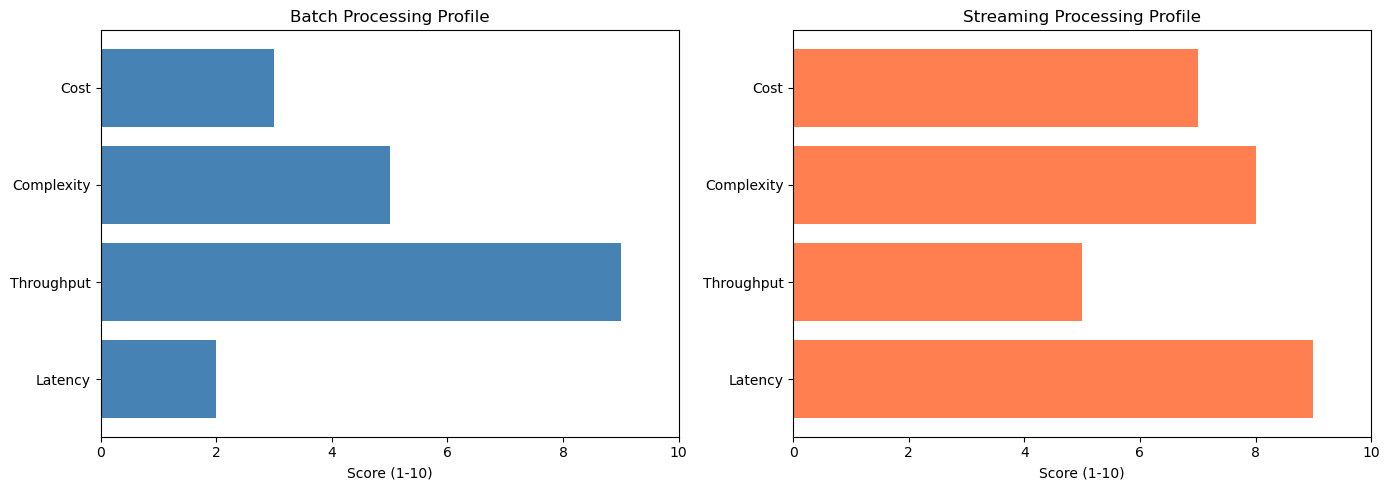


Trade-offs Summary:
Batch:     Higher latency, higher throughput, simpler control, lower cost
Streaming: Lower latency, moderate throughput, higher complexity, higher cost


In [11]:
# Visualization: Batch vs. Streaming characteristics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Batch processing characteristics
categories = ['Latency', 'Throughput', 'Complexity', 'Cost']
batch_scores = [2, 9, 5, 3]  # 1-10 scale
ax1 = axes[0]
ax1.barh(categories, batch_scores, color='steelblue')
ax1.set_xlabel('Score (1-10)')
ax1.set_title('Batch Processing Profile')
ax1.set_xlim(0, 10)

# Streaming processing characteristics
streaming_scores = [9, 5, 8, 7]
ax2 = axes[1]
ax2.barh(categories, streaming_scores, color='coral')
ax2.set_xlabel('Score (1-10)')
ax2.set_title('Streaming Processing Profile')
ax2.set_xlim(0, 10)

plt.tight_layout()
plt.show()

print('\nTrade-offs Summary:')
print('Batch:     Higher latency, higher throughput, simpler control, lower cost')
print('Streaming: Lower latency, moderate throughput, higher complexity, higher cost')


### Interpreting the Trade-off Visualization

The charts above show how batch and streaming systems trade off different properties.

**Batch Processing**
- Latency is not the priority; the system waits for data to accumulate.
- Throughput is high because large volumes are processed together.
- Operational logic is simpler because the input boundary is explicit.
- Cost is usually lower when freshness is not business-critical.

**Streaming Processing**
- Latency matters because the system reacts while the signal is still fresh.
- Throughput per event is lower because the platform stays live continuously.
- Complexity rises because ordering, lateness, and state retention become real concerns.
- Cost rises because the infrastructure remains active all the time.

The key insight is the same one used throughout Chapter 1: you cannot optimize latency, throughput, simplicity, and cost simultaneously. Retail ranking usually pushes toward low-latency event handling. A support assistant may keep document ingestion in batch while still needing low-latency retrieval and prompt-context assembly at response time.


## Part 2A: Compare the Two Live Paths

The generic batch-versus-streaming chart is still useful, but Chapter 1 becomes more concrete when the two recurring reference systems are compared directly.


In [1]:
two_track_comparison = pd.DataFrame([
    {
        'runtime_path': 'retail session events',
        'main_live_state': 'clicks, cart events, session counters',
        'why_online': 'ranking changes while the session is live',
        'quiet_failure': 'missing event field or stale feature counter',
        'evidence_needed': 'event replay plus feature freshness markers',
    },
    {
        'runtime_path': 'retrieval-time context assembly',
        'main_live_state': 'retrieved chunks, prompt template, tool output',
        'why_online': 'the answer depends on request-time context assembly',
        'quiet_failure': 'stale corpus snapshot or missing tool trace',
        'evidence_needed': 'prompt trace plus retrieved chunk identifiers',
    },
])
two_track_comparison


NameError: name 'pd' is not defined

### Expected Answer

Prompt templates, retrieved chunks, and tool traces belong in the same platform conversation as features and labels because all of them are model-facing assets. They change what the model learns from, sees at runtime, or can be evaluated against later. Once they influence behavior directly, they need the same versioning, replay, ownership, and evidence discipline as classical ML assets.


## Key Takeaways

1. **Data engineering is foundational**. Models are only one part of the system; features, labels, benchmarks, embeddings, prompts, and traces all matter.
2. **The retail and support-assistant tracks are deliberately paired**. One emphasizes feature and label discipline; the other emphasizes retrieval, prompt, and context discipline.
3. **Prompting changes category in production**. Casual prompting is a one-off interaction. Production prompt and context engineering uses versioned templates, durable traces, benchmark testing, and release ownership.
4. **Architecture trade-offs are operational**. Batch versus streaming is not only about speed. It changes replay, observability, and how failures surface.

## Exercises

### Concept check
- Define model-facing data, quiet failure, and the first contract that usually breaks when assets are not versioned.

### Diagnostic scenario
- Use the dashboard-to-recommendation scenario from Chapter 1 and state when it becomes AI data engineering, which assets become model-facing, and which quiet failure appears first.

### Artifact-building exercise
- Fill a six-contract map for either the retail ranking system or the retrieval-based support assistant. Use columns for what must be explicit, first likely failure if missing, and evidence needed.

### Notebook extension
- Revisit the broken asset table. Choose two broken assets, identify the first production symptom, the missing evidence, the owner who should have been responsible, and the contract under pressure.

## Suggested Follow-Through

- Review Chapter 1 in the book for the diagnostic worksheet and the prompt-versus-context contrast.
- Use the notebook as a boundary test: when does your own system stop being an analytics workflow and become an AI platform?
- Move next to `02_data_ingestion.ipynb` to inspect how those assets first enter the platform.